# Introduction to Statistics - Assignment

The purpose of this assignment is to demonstrate that you understand fundamental statistical techniques, can use Python competently and can interpret the output. Do not assume that the analyses requested here would in practice be performed on this data; this is an exercise intended to allow you to show your understanding of basic statistics and your competence in using Python to carry out a range of statistical techniques.

Always remember when reviewing results that statistical significance does not mean clinical importance; for a dataset with many subjects a small and unimportant difference in what you are testing may give statistical significance.

Also remember that the purpose of this assignment is to assess your understanding of statistics. You are not expected to interpret the results in clinical or biological terms. When commenting on the results or making observations, please comment only on the relevant *statistical* aspects.

The assignment is based on a study to understand the prevalence of obesity, diabetes, and other cardiovascular risk factors in central Virginia for African Americans. Please read the [description of the data in the README document](https://github.com/jdtournier/MedPhysCourseAssignment/blob/main/README.md).

Remember as you consider your results that the population from which this sample was taken is not the general population of African Americans. This is a selected dataset – those subjects who were actually screened for diabetes.


# HOW TO CARRY OUT THIS ASSIGNMENT:

**Please make a copy of this notebook**, then provide your answers to the questions in the spaces provided. You are free to use as much space as you feel is needed to answer the question, but bear in mind that it's usually sufficient to write a few short sentences.

Once completed, please download your notebook as a `.ipynb` file (using the File → Download → download .ipynb menu), or alternatively download it from the 'Colab Notebooks' folder on your Google Drive. You can then submit this file as-is via KEATS.

**Make sure to fully justify any decisions you make,visualise the data where relevant, and investigate any assumptions made.** In particular:

-	where the output offers a choice of test and/or result you need to give some indication of why you made the choice you did

-	if possible an explanation of what the test statistic (e.g. *t*) actually means

-	an explanation of what the *p*-value really means

-	what conclusions you would draw from the results

-	any other comments you consider relevant to explain the results or justify their validity.

- where the questions asks for a model, don't forget to state the final equation for the model.

**Use as many text or code boxes as you need to answer the question!**

# Preamble

The code below loads all required modules and the data to be investigated. You can find the list of functions available [on this page](https://github.com/jdtournier/MedPhysStatsCourse).

Allow this section to run without modification!

In [1]:
import urllib
url = 'https://raw.githubusercontent.com/jdtournier/MedPhysStatsCourse/main/stats_course.py'

with open ('stats_course.py', 'wb') as data:
  data.write (urllib.request.urlopen(url).read())

from stats_course import *

df = load_data ('https://github.com/jdtournier/MedPhysCourseAssignment/raw/main/diabetes%20-%20raw%20data.csv')

# Before you start!

We need to perform a few steps to clean up the data first:

In [2]:
df.set_index ('id', inplace=True)
df.columns = [c.replace(".", "_") for c in list(df.columns)]

# Q1. Assess mean BMI	_[15 marks]_

According to the National Health and Nutrition Examination survey, the average BMI in the United States is 26.55 (average of both sexes).

- Compute a new variable `bmi` defined as 703×`weight`/`height`² (a correction factor of 703 is necessary when using pounds and inches).

- Perform the necessary steps to assess whether the mean BMI of the subjects in this dataset is significantly different from the general population.

- Explain the output & summarise your conclusions.

# Answer
**Null hypothesis(H0)**: There is no significant difference in mean BMI between the population and the sample i.e the BMI of the sample is 26.55

**Alternative hypothesis (H1)**: There is a significant difference in BMI between the population and the sample i.e. the BMI of the sample is not 26.55.

If p<=0.05, the result is statistically significant and we reject the null hypothesis.[link text](https://)

In [3]:
df['bmi'] = 703*df['weight']/df['height']**2 #function to create column and calculate bmi
bmi_mean_s = df['bmi'].mean() #calculate mean of sample
bmi_mean_s
bmi_mean_p = 26.55 #define mean bmi of population
stats.ttest_1samp(df.bmi, bmi_mean_p, nan_policy='omit') #one sample two-tailed t-test

TtestResult(statistic=np.float64(6.739969312126765), pvalue=np.float64(5.611731867532117e-11), df=np.int64(396))

Since p=5.612e-11 then p < 0.05, therefore we **reject** the null hypothesis.

There is strong evidence to suggest that
We are 95% confident that
the mean BMI of the sample is significantly different than the mean of the population
i.e. the mean of the sample is significantly different than the mean of the population (26.55).

5 in 100 million***

# Q2. Compare BMI between subjects with and without diabetes _[10 marks]_

-	Compute a new variable `diabetes` computed as Glycosolated haemoglobin (`glyhb`) > 7

- Compare mean BMI between those diagnosed with diabetes and those not diagnosed with diabetes.

- Explain the output & summarise your conclusions.

# Answer
**Null hypotheis (H0)**: the mean BMI of persons with diabetes is not significantly different from the mean BMI of persons without diabetes
**Alternative hypothesis (H1)**: the mean BMI of persons with diabetes is significantly different from the mean BMI of persons without diabetes

If p<=0.05, the result is statistically significant and we reject the null hypothesis.

In [ ]:
#function to determine if patient has diabetes from glycosolated haemoglobin. Adds a column in dataframe with 'True' if glyhb >7 so patient is diabetic or 'False' for glyhb<=7 so patient is not diabetic.
def diagnose_diabetes (gly_hyb):
  df['diabetes'] = df['glyhb'] > 7
  return df
diagnose_diabetes(df['glyhb']) #call function

#iterate through each row. Creates a column with bmi for each diabetic patient and another column containing the bmi of non-diabetic patients
for index, row in df.iterrows():
  if row['diabetes'] == True:
    df.loc[index, 'diabetic'] = row['bmi']
  else:
    df.loc[index, 'non_diabetic'] = row['bmi']

#print mean bmi of diabetic and non-diabetic patients
print('The mean BMI of diabetic patients:', df.diabetic.mean())
print('The mean BMI of nondiabetic patients:', df.non_diabetic.mean())

#Performs independent 2-tailed two test to compare the mean of bmi of diabetic patients with the mean bmi of non-diabetic patients
stats.ttest_ind(df.diabetic, df.non_diabetic, nan_policy='omit')


The mean BMI of diabetic patients: 30.986084169961558
The mean BMI of nondiabetic patients: 28.407909942378826


TtestResult(statistic=np.float64(2.769664292460764), pvalue=np.float64(0.005876109553662416), df=np.float64(395.0))

Since p=0.0058 then p < 0.05, we can **reject** the null hypothesis.

There exist evidence to sugguest that the BMI of persons with diabetes is significantly different from those without diabetes.
i.e the mean of BMI for persons with diabetes (30.986) is significantly different from the mean of BMI for nondiabetic persons (28.408)
6 in 1000***

# Q3. Investigate relationship between diabetes and hypertension _[15 marks]_

Hypertension is defined as systolic blood pressure > 140.

- Compute a new variable `hypertension` as first systolic blood pressure (`bp_1s`) > 140

- What percentage of subject with `diabetes` also have `hypertension`?

- Perform the requisite steps to assess the relationship between `diabetes` and `hypertension`.

- Explain the output & summarise your conclusions.


# Answer
**Null hypothesis (H0):** There is no difference in the proportion of subjects who are diabetic and who are not in the general population, who also have hypertension.
**Alternative hypothesis (H1):** There is a difference in the proportion of subjects who are diabetic and who are not in the general population, who also have hypertension.

In [ ]:
df['hypertension'] = df['bp_1s'] > 140 #function to create column and calculate if patient has hypertension
print(df.hypertension.value_counts()) #count and print number of patients with hypertension
print(df.diabetes.value_counts()) #count and print number of patients with diabetes
print(df.hypertension.loc[df.diabetes == True].value_counts()) #count and print number of patients with hypertension and diabetes

diab_hyp = (df.hypertension.loc[df.diabetes == True].value_counts()[True])/(df.diabetes.value_counts()[True])*100 #calculate percentage of patients with diabetes and hypertension
print('The percentage of subject with diabetes who also have hypertension is', diab_hyp)

hypertension
False    272
True     131
Name: count, dtype: int64
diabetes
False    343
True      60
Name: count, dtype: int64
hypertension
True     37
False    23
Name: count, dtype: int64
The percentage of subject with diabetes who also have hypertension is 61.66666666666667


In [ ]:
#Perform chi-squared test to test independence of diabetes and hypertension
table = sm.stats.Table.from_data(df[['hypertension', 'diabetes']]) #create crosstable with relevant tabs (subjects with hypertension and subjects with diabetes)
table.table_orig
table.fittedvalues
chi=table.test_nominal_association() #perforn chi-squared test
print(chi) #print results of chi-squared test

df          1
pvalue      1.7219337167251325e-07
statistic   27.322529615717606


p value = 1.721e-7 is much less than 0.05, therefore we **reject** the null hypothesis.
This means that there is a signficant difference in the proportional of diabetic and non-diabetic patients with hypertension at the 5% signifance level.
If there was no statistical significance, there would be a **2 in 10 million** chance getting this result.
There is evidence to suggest that patients with diabetes are more likely to have higher first systolic readings, hence, hypertension.


# Q4. Distribution of Cholesterol/HDL ratio	_[15 marks]_

Consider the distribution of Cholesterol/HDL ratio values (`chol_ratio` = `chol`/`hdl`). We have a lot of subjects, so for some analyses there is no problem with the distribution, but for other analyses it might be more helpful if the distribution was more normal.

- Is there a problem with the distribution of Cholesterol/HDL values? Present summary statistics and any plots you feel are appropriate to support your conclusions.

- How would you address this issue? Present histograms to show your conclusions.

# Answer


In [ ]:
df['chol_ratio'] = df['chol']/df['hdl'] #compute ratio of cholesterol to HDL and add column to df
df['chol_ratio'].describe() #print summary statistics of chol_ratio

,chol_ratio
count,402.000000
mean,4.525892
std,1.725800
min,1.487179
25%,3.218681
50%,4.260870
75%,5.424013
max,19.260870


range of data = min to max, therefore, range of data =1.487179 to 19.260870

median is equal to the 50% or 2nd quartile, therefore median = 4.26087

1st quartile = 25% quartile = 3.218681

3rd quartile = 75% quartile = 5.424013

In [ ]:
skewness = 3*(df['chol_ratio'].mean()-df['chol_ratio'].median())/df['chol_ratio'].std() #calculate Pearson skewness coefficient of chol_ratio
print('Pearson skewness coefficient =', skewness) #print Pearson skewness coefficient values

Pearson skewness coefficient = 0.46069536153214785


Mean tends to be more heavily influenced than median by skewness. Mean of sample found to be 4.53 while median found to be 4.26. This shows very small right or positive skewness since the mean is slightly larger than the median. It is difficult to comment on the significance between the mean and median by only assessing the descriptive statistics.
Pearson skewness coefficient can be used to assess the level of skewness. Coefficient values range from -1 to 1, with a value of 0 representing perfectly symmetrical distribution. A skewness coefficient of 0.49 represents moderate positive skewness, hence the data is not a perfect normal distribution.

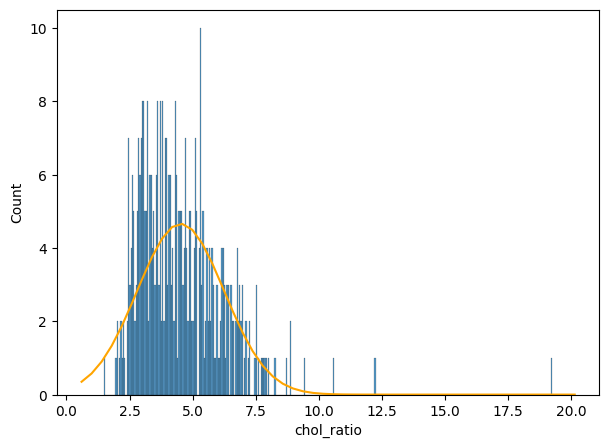

In [ ]:
#plot histogram of chol_ratio with normal curve overlay
y=df['chol_ratio'] #define y variable to be plotted
width = 0.05 #bin width
ax=sns.histplot(data=y, binwidth=width) #plot histogram
x = np.linspace (ax.get_xlim()[0], ax.get_xlim()[1]) #set locations to evaluate normal distribution
ax.plot (x, width*len(y)*stats.norm.pdf(x, y.mean(), y.std()), color='orange') #use mean and std to add curve to graph

Distribution is mostly normal but slighly positively skewed, as in descriptive statistics above. There are more values on the left with more extreme values on the right.

<Axes: ylabel='chol_ratio'>

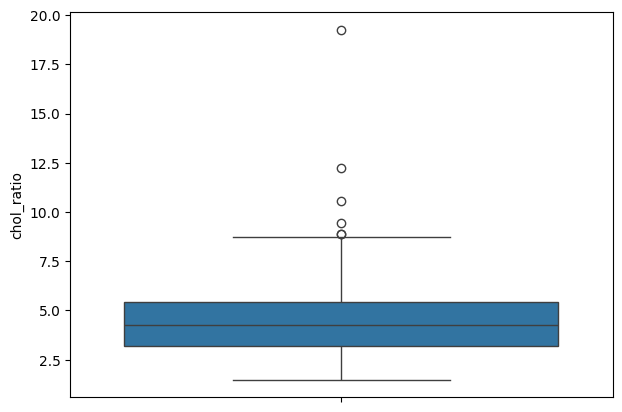

In [ ]:
#plot boxplot to show chol_ratio distribution
sns.boxplot (data=df['chol_ratio'])

The boxplots show positive outliers which cause positive skewness observed in histoplot. Outliers are more than 1.5 x IQR but less than 3 x IQR.
Remove outliers can reduce skewness and create normal distribution.

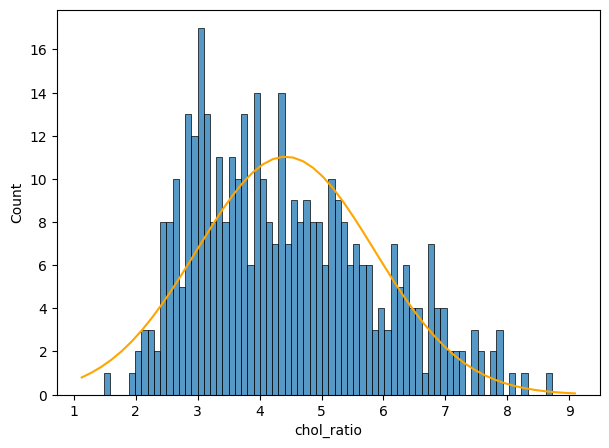

In [ ]:
#Remove outliers which are values beyond 1.5 times the IQR from the quartiles
Q1 = df['chol_ratio'].quantile(0.25) #calculate 1st quartile
Q3 = df['chol_ratio'].quantile(0.75) #calculate 3rd quartile
IQR =  df['chol_ratio'].quantile(0.75) - df['chol_ratio'].quantile(0.25)# calculate interquartile range
remove_outliers = df[~((df['chol_ratio'] < (Q1 - 1.5 * IQR)) | (df['chol_ratio'] > (Q3 + 1.5 * IQR)))] #stores chol_ratio values that are not outliers

#Plot histogram of chol_ratio without outliers with normal curve overlay
y = remove_outliers['chol_ratio']
width = 0.1
ax = sns.histplot(data=y, binwidth=width)
x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1])
ax.plot(x, width * len(y) * stats.norm.pdf(x, y.mean(), y.std()), color='orange')

Once the outliers have been removed, the dispersion of data looks more like the normal distribution curve. There is little to no skewness.

# Q5. Relate stabilized glucose to glycosolated haemoglobin in diabetes cases	_[15 marks]_

- Select those cases with a diagnosis of diabetes

- Create a simple linear regression model to relate stabilized glucose (independent variable) to glycosolated hemoglobin (dependent variable)

- Comment on the model & its generalisability.

# **Answer**
**Null hypothesis (H0):** Stabilised glucose (stab_glu) has no effect on glycosated haemoglobin (glyhb)

**Alternate hypothesis (H1):** There is correlation between stabilised glucose (stab_glu) and glycosated haemoglobin (glyhb)

If p <0.05 then reject the null hypothesis.

In [ ]:
#perform linear regression
linear_regression = smf.ols('glyhb ~ stab_glu', data=df.loc[df.diabetes == True]).fit()
#.loc[df.diabetes == True] selects values only for patients who have been diagnosed with diabetes i.e glyhb>7print(linear_regression.summary())
print(linear_regression.summary()) #print summary statistics of the linear regression

                            OLS Regression Results                            
Dep. Variable:                  glyhb   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     19.91
Date:                Fri, 09 May 2025   Prob (F-statistic):           3.80e-05
Time:                        04:57:05   Log-Likelihood:                -125.48
No. Observations:                  60   AIC:                             255.0
Df Residuals:                      58   BIC:                             259.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.2389      0.699     10.350      0.0

*   P>t = 0 represents a p-value that is less than the level of significance of 0.05. Therefore, we **reject** the null hypothesis.  Glycosated haemoglobin is controlled by or correlates to stabilised glucose.

*   F-statistic probability = 0.000038 which is smaller than significance value of p = 0.05. Therefore we **reject** the null hypothesis. There is significant results to suggest that glycosated haemoglobin can be explained by stabilised glucose.


*   R squared of 0.256 means that 25.6% of stabilised glucose can be explained by glycosated haemoglobin.


*   The adjusted R-squared value is only slightly lower than R-squared as there is only one dependent variable tested.


# Assessing residuals

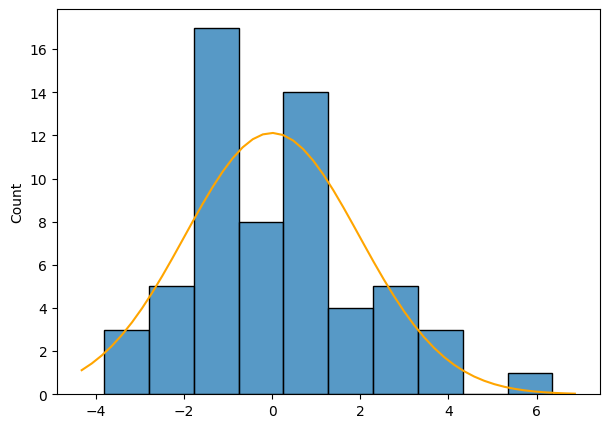

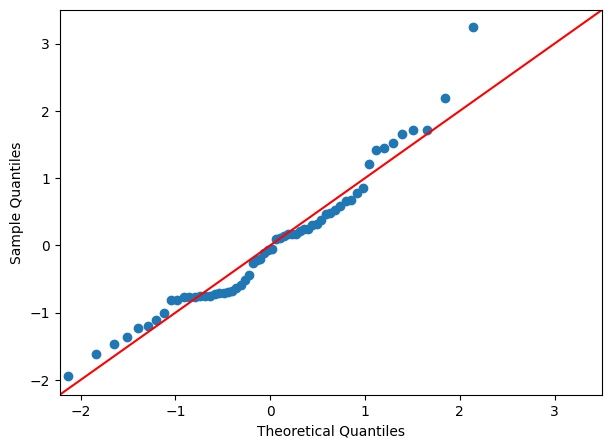

In [ ]:
ax = sns.histplot (linear_regression.resid, binwidth=1) #create histoplot of the residuals from linear regression
add_Normal (ax, linear_regression.resid, 1); #add normal line to hisplot
sm.qqplot(linear_regression.resid, fit=True, line="45"); #create QQ plot of residuals

The histoplot shows a mostly normal distributon of residuals with a slight right skewness. This may mean that there are positive outliers. There are also peaks and throughs at the centre of the curve which show some deviation from the normal distribution.

The quartile-quartile (QQ) plot shows that the residuals roughly follow the predicted values. Deviation is seen on the far right which shows that there are positive outliers within the residuals. This aligns with right sided skewness observed in the histoplot.


**Generalisability of the model**
While there is statistical significance showing that glycosated haemoglobin is controlled by stabilised glucose, the model only explains 25% of the variance. This means that there may be other factors affecting/controlling glycosated haemoglobin. Also, the residuals demonstrate a small positive (right sided) skewness which will affect its ability to be generalised. Only one predictor was used in the model so there is little chance of overfit of the model, however, the sample size of 60 is not very large and may not be representative of the population. This model is ideal for modeling of this sample, but may not be generalisable to the entire population.

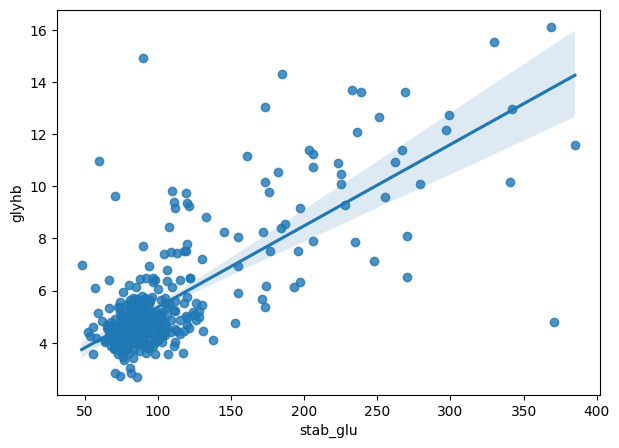

In [ ]:
sns.regplot (data=df, x='stab_glu', y='glyhb');

# Q6. Find the best model to predict glycosolated haemoglobin	_[15 marks]_

Use the *p*-value-based  backward selection method to identify the most appropriate model to predict glycosolated haemoglobin (`glyhb`) within the subjects diagnosed as having diabetes.

- Include the following variables: `stab_glu`, `chol`, `hdl`, `chol_ratio`, `age`, `weight`, `height`, `bmi`, `waist`, `hip`, `bp_1s`, `gender`, `location`

- Comment on the model & its generalisability.

In [ ]:
#Backward stepwise multiple linear regression based on p-value
#variables = ['stab_glu', 'chol', 'hdl', 'chol_ratio', 'age', 'weight', 'height', 'bmi', 'waist', 'hip', 'bp_1s', 'gender', 'location'] #define variables to be assessed in model
#gender and location found to not be signficant but caused error so removed manually
variables = ['stab_glu', 'chol', 'hdl', 'chol_ratio', 'age', 'weight', 'height', 'bmi', 'waist', 'hip', 'bp_1s'] #define variables to be assessed in model
result = stepwise_backward_pval(df.loc[df.diabetes == True], 'glyhb', variables) #perform backward stepwise method
print(result.summary()) #print summary of results of backward stepwise method


  glyhb ~ stab_glu + chol + hdl + chol_ratio + age + weight + height + bmi + waist + hip + bp_1s : R² = 0.36145336490788593
    Intercept, p = 0.150703590221915
    stab_glu, p = 9.406053717033613e-05
    chol, p = 0.046233089435516954
    hdl, p = 0.8109896119730602
    chol_ratio, p = 0.5647343958514237
    age, p = 0.21081786100110067
    weight, p = 0.28354517010852365
    height, p = 0.29735028628880195
    bmi, p = 0.1443537845450008
    waist, p = 0.9233030092810145
    hip, p = 0.15390428812385926
    bp_1s, p = 0.01849085856823452

removing waist with p = 0.9233030092810145

  glyhb ~ stab_glu + chol + hdl + chol_ratio + age + weight + height + bmi + hip + bp_1s : R² = 0.37491214939611206
    Intercept, p = 0.14452629843754608
    stab_glu, p = 7.392085401555489e-05
    chol, p = 0.04399299522494703
    hdl, p = 0.8079951950049069
    chol_ratio, p = 0.5622007111123983
    age, p = 0.1810486452117316
    weight, p = 0.2802621423204932
    height, p = 0.2886531493917071
    bmi

The final model shows that there is a statistical significant relationship between stablised glucose, cholestol, bmi and first systolic blood pressure with glycosated haemoglobin in patients diagnosed with diabetes.

The predicted model follows the equation 11.5635 + 0.0138stab_glu + 0.0135chol - 0.0730bmi - 0.0338bp_1s.

The F-statistic value of 0.00000528 is less than signifiance level of 0.05, therefore, the model shows statistical significance between the variables and glucosated haemoglobin.

R-squared value is 0.425 which means that the model explains 42.5% of the variance in glycosated haemoglobin.
The adjusted R-squared value of 0.381 accounts for multiple predictors within the model and adjusts for overfitting.

The p-values for the variables show that stabilised glucose (p=0.000), cholesterol (p=0.005) and bmi (p = 0.008) are statistically significant. BMI has a p-value of 0.056 which is not quite statistically significant. While it may have some effect on glycosated haemoglobin, it is not a strong predictor.

**Generalisability of the model**
-Multicollinearity means that variables may correlate with each other making it difficult to use the model as a predictor.
-R value shows that the model only explains 42.5% of variance. Still a large amount of unexplained variance
-Sample size of 58 is not large so data may not be generalisible to the population.


# Q7. Prediction of diagnosis of diabetes _[15 marks]_

-	Create a new variable `wh_ratio` computed as the ratio of `waist` to `hip`
- Use binary logistic regression to assess whether it is possible to predict diagnosis of diabetes from a combination of some or all of the following risk factors:

  - age > 60
  - body mass index > 30
  - gender
  - waist/hip ratio > 1
  - cholesterol/HDL ratio > 7
  - hypertension

- Summarise the main conclusions.

In [ ]:
df['wh_ratio'] = df['waist']/df['hip'] #compute wh_ratio by dividing waist by hip and adding column to df
df.head()
# edit this line df['survived'] = [ 1 if x=='SURVIVED' else 0 if x=='DIED' else np.nan for x in df['outcome'] ] #convert gender to numerical value 1 for Male and 0 for Female
#edit this line df['survived'] = [ 1 if x=='SURVIVED' else 0 if x=='DIED' else np.nan for x in df['outcome'] ] #convert hypertension to numerical value 1 for True and 0 for False

,chol,stab_glu,hdl,glyhb,location,age,gender,height,weight,frame,...,waist,hip,time_ppn,wh_ratio,hypertension,bmi,diabetes,non_diabetic,diabetic,chol_ratio
id,,,,,,,,,,,,,,,,,,,,,
1000,203.0,82,56.0,4.31,Buckingham,46,female,62.0,121.0,medium,...,29.0,38.0,720.0,0.763158,False,22.128772,False,22.128772,NaN,3.625000
1001,165.0,97,24.0,4.44,Buckingham,29,female,64.0,218.0,large,...,46.0,48.0,360.0,0.958333,False,37.415527,False,37.415527,NaN,6.875000
1002,228.0,92,37.0,4.64,Buckingham,58,female,61.0,256.0,large,...,49.0,57.0,180.0,0.859649,True,48.365493,False,48.365493,NaN,6.162162
1003,78.0,93,12.0,4.63,Buckingham,67,male,67.0,119.0,large,...,33.0,38.0,480.0,0.868421,False,18.635999,False,18.635999,NaN,6.500000
1005,249.0,90,28.0,7.72,Buckingham,64,male,68.0,183.0,medium,...,44.0,41.0,300.0,1.073171,False,27.822016,True,NaN,27.822016,8.892857
